<div align="left">
    <img src="../assets/Qgorithm_logo.png" width="180">
</div>

**Author:** Emad Rezaei Fard Boosari

📺 YouTube: https://youtube.com/@qgorithm

💼 LinkedIn: https://linkedin.com/in/your-linkedin

# Introduction

Grover's Search Algorithm is one of the most famous quantum algorithms.

It provides a quadratic speedup for searching an unstructured database of $N$ items, requiring approximately $O(\sqrt{N})$ queries instead of $O(N)$ classical queries.

In this notebook, we implement Grover's algorithm using Qiskit and analyze how amplitude amplification increases the probability of finding the marked state.

# Grover's Search with Multiple Marked States

In [1]:
from qiskit import *
from qiskit_aer import *
from qiskit.visualization import *
from qiskit.quantum_info import *

import numpy as np

## Visualizatin function

In [2]:
def qplot(x):
    return x.draw(scale=0.8, fold=-1, cregbundle=True, initial_state=True)

## Multi-Item Search

In the previous notebook, we considered the case where only a single state was marked by the oracle.

In many practical applications, however, there may be multiple valid solutions. Grover's algorithm can also be used in this setting by marking all desired states simultaneously.

> In this example, we search for the two target states
- `|1010⟩`  
- `|1100⟩`
within a search space of 16 possible states.

### Differences from Single-Item Search

Compared to the single-item case, two aspects of the algorithm change:

#### 1. Oracle Construction

The oracle must apply a phase flip to every marked state.

Instead of marking a single state,

$$|w⟩ → −|w⟩$$

the oracle now marks multiple states:

$$|1010⟩ → −|1010⟩$$

$$|1100⟩ → −|1100⟩$$

All other basis states remain unchanged.

#### 2. Number of Grover Iterations

When multiple solutions exist, the optimal number of Grover iterations becomes

$$ k \approx \frac{\pi}{4}\sqrt{\frac{N}{d}} $$

where:

* N is the size of the search space,
* d is the number of marked states.

For this example:

* N = 16
* d = 2

which requires fewer Grover iterations than the single-item case.


## Constructing the Oracle

The following circuit implements an oracle that simultaneously marks the states `|1010⟩` and `|1100⟩`.

Each marked state receives a phase flip, while all remaining states are left unchanged.

## Building a Gate for Grover Operator

In [16]:
# Number of qubits
n = 4

# create quantum Circuit
cirq = QuantumCircuit(n)

# oracle for |1010>, and |1100>

## |1010>
cirq.x(0)
cirq.x(2)
cirq.h(-1)
cirq.mcx([i for i in range(n-1)], n-1)
cirq.h(-1)
cirq.x(0)
cirq.x(2)
#cirq.barrier()
## |1100>
cirq.x(0)
cirq.x(1)
cirq.h(-1)
cirq.mcx([i for i in range(n-1)], n-1)
cirq.h(-1)
cirq.x(0)
cirq.x(1)
#cirq.barrier()

# Applying diffuser
cirq.h(range(4))
cirq.x(range(4))
cirq.h(-1)
cirq.mcx([i for i in range(n-1)], n-1)
cirq.h(-1)
cirq.x(range(4))
cirq.h(range(4))

G = cirq.to_gate()
G.name = 'G_mulit'


qplot(cirq)

┌───┐     ┌───┐┌───┐     ┌───┐┌───┐┌───┐          ┌───┐┌───┐     
q_0: |0>┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
        └───┘  │  ├───┤└───┘  │  ├───┤├───┤├───┤       │  ├───┤├───┤     
q_1: |0>───────■──┤ X ├───────■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
        ┌───┐  │  ├───┤       │  ├───┤├───┤└───┘       │  ├───┤├───┤     
q_2: |0>┤ X ├──■──┤ X ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├─────
        ├───┤┌─┴─┐├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐┌───┐┌─┴─┐├───┤├───┤┌───┐
q_3: |0>┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├
        └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘

In [18]:
iter = int(np.floor((np.pi/4)*(np.sqrt(2**(n-1)))))
iter

2

## Quantum Circuit for Search

In [21]:
qc = QuantumCircuit(n,n)

# Applying Hadamard gates
qc.h(range(n))
qc.barrier(label = 'H^4')

# Applying the Grover's operator
for i in range(iter):
    qc.append(G, [i for i in range(n)])

# Measurement
for i in range(n):
    qc.measure(i,i)


qplot(qc)

┌───┐ H^4 ┌──────────┐┌──────────┐┌─┐         
q_0: |0>┤ H ├──░──┤0         ├┤0         ├┤M├─────────
        ├───┤  ░  │          ││          │└╥┘┌─┐      
q_1: |0>┤ H ├──░──┤1         ├┤1         ├─╫─┤M├──────
        ├───┤  ░  │  G_mulit ││  G_mulit │ ║ └╥┘┌─┐   
q_2: |0>┤ H ├──░──┤2         ├┤2         ├─╫──╫─┤M├───
        ├───┤  ░  │          ││          │ ║  ║ └╥┘┌─┐
q_3: |0>┤ H ├──░──┤3         ├┤3         ├─╫──╫──╫─┤M├
        └───┘  ░  └──────────┘└──────────┘ ║  ║  ║ └╥┘
 c: 0 4/═══════════════════════════════════╩══╩══╩══╩═
                                           0  1  2  3

## Measurement Results

After applying the optimal number of Grover iterations, we measure the quantum register.

The probability amplitudes of the marked states have been amplified, making them much more likely to be observed than the remaining basis states.

Ideally, the measurement outcomes should be concentrated around `|1010⟩` and `|1100⟩`.


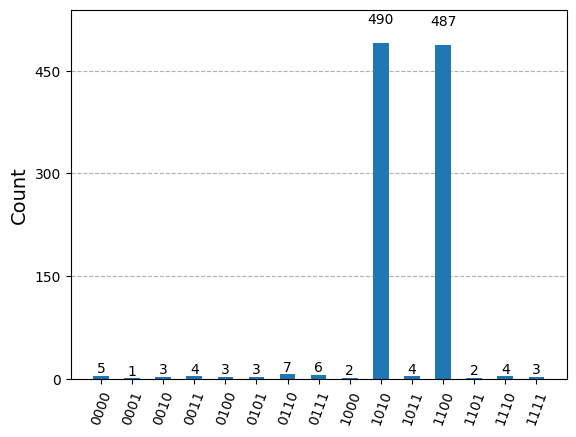

In [23]:
backend = QasmSimulator()
t_qc = transpile(qc, backend)
job = backend.run(t_qc)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)